In [15]:
# Importing modules
import transformers
import matplotlib.pyplot as plt

In [4]:
# importing model
from transformers import GPT2LMHeadModel
hf_gpt=GPT2LMHeadModel.from_pretrained("gpt2") #gpt2-124M model

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [7]:
# Exploring state dictionary of model
# the state dict gives us total number of tensors in the model like weights, biases, layer norm parameters etc
sd=hf_gpt.state_dict()
print(len(sd))
for k,v in sd.items():
    print(k,v.shape) #50257 tokens, 768 dimensional embedding, 1024 position length

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

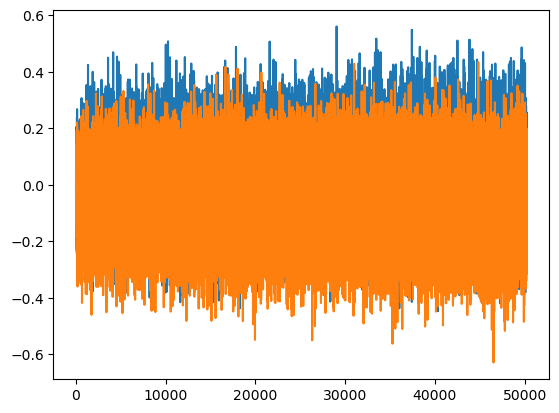

In [19]:
# Visualizing token embeddings
# plt.imshow(sd["transformer.wte.weight"],cmap="gray") - not much info
plt.plot(sd["transformer.wte.weight"][:,150]) # token 150
plt.plot(sd["transformer.wte.weight"][:,200]) # token 200

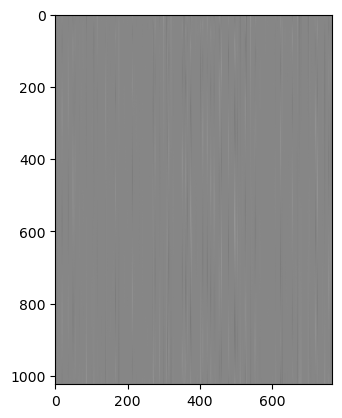

In [10]:
# Visualizing positional encodings

plt.imshow(sd["transformer.wpe.weight"],cmap="gray") # each row is a position and column is a dimension

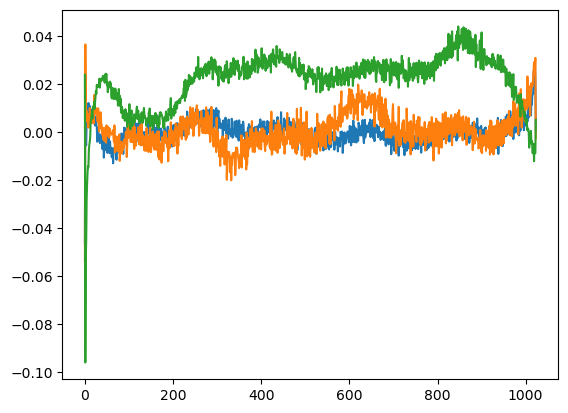

In [14]:
# Visualizing specific positional encodings
# specific dimensions visualized as a function of position from 0 to 1023
# more trained would be smoother curves
# in gpt2, these are trained parameters unlike original Attention paper which fixed alternating sinusoidal and cosine curves
plt.plot(sd["transformer.wpe.weight"][:,150])
plt.plot(sd["transformer.wpe.weight"][:,200])
plt.plot(sd["transformer.wpe.weight"][:,250])

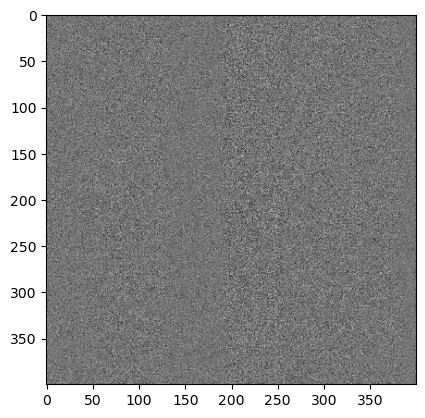

In [26]:
# visualizing attention_head
plt.imshow(sd["transformer.h.0.attn.c_attn.weight"][:400,:400], cmap="gray")

In [27]:
# Exploring model pipeline
from transformers import pipeline, set_seed
generator=pipeline("text-generation",model="gpt2")
set_seed(42)
generator("Hello, I'm a language model", max_length=30, num_return_sequences=5)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language modeler. I use the standard C++ compiler for my code, and C++ code is probably the best way to learn C++. So, I'm not going to let you have a bad day, you're welcome, I just want to make a note of my code and know what you're thinking about.\n\nThere's a lot of stuff in my code that I'm not using and I'm not going to get it right. But I'll try to do it with good practice, and use my code to write nice things.\n\nWhy are you using C++?\n\nWhy did you choose C++? Well, I was just getting started with C++, and it was a nice language, so I think in the end that's what I like about C++. And actually, I think that a lot of people use C++, and I think that they're going to find a lot of things to love about it.\n\nSo I think that's why I chose C++, is because I think that a lot of people like these languages, so I think people really like these languages, and I think that's what I like about them.\n\nSo I think that's why I chose C++, because I think